# Closed-loop BeamNG control with the fine-tuned `YOLOPControlNet`

This notebook is the "next step" described at the end of `1 Fine Tuning.ipynb`:
it opens BeamNG, drives a real closed loop, and lets the model trained in that notebook
(`artifacts/yolop_control_head_masked_best.pt`, the masked-frame model -- see section 2 below)
steer/brake the car -- no hand-written PID for those two, the corrected steer/brake come
straight out of the network.

`YOLOPControlNet` only has two outputs now: **steer** and **brake**. Throttle/acceleration is
never read from the model -- it comes from `cruise_control_throttle` (section 4 below), a
simple non-adaptive cruise controller that just holds a fixed target speed and has no access
to the camera frame or the model's brake decision. This split exists because the previous
3-output model let comma2k19's emergency-brake frames teach the shared fusion head a spurious
"max brake -> wheel centered" shortcut, which collapsed steering whenever BeamNG's bridge/
overpass shadows triggered the brake output.

Each loop iteration does exactly this:

```
[BeamNG advances one physics step] -> [ask BeamNG for a camera frame + current telemetry]
   -> [send that to YOLOPControlNet, run locally, get (steer, brake)]
   -> [get throttle from the separate non-adaptive cruise controller]
   -> [send steer + throttle + brake back to BeamNG]
```

## Prerequisites checked by this notebook

1. `tech.key` (your approved BeamNG.tech license) sitting in the repo root -- this notebook
   installs it into the userpath BeamNG actually launches with.
2. `artifacts/yolop_control_head_masked_best.pt` -- the masked-frame checkpoint produced by
   `1 Fine Tuning.ipynb` (already present in this repo). Section 2 loads this and section 5
   defaults `LANE_MASK_MODE` to `"road"` to match how it was trained -- both must move together
   if you switch checkpoints.
3. BeamNG.drive **closed** before you run the connection cell (the launcher needs to start
   it itself with the right `-userpath`).

If you want the classical, non-learned alternative (PID lane-keeping/ACC instead of the
network), see `NEXT_STEPS.md` / `plan.md` -- this notebook is the learned-model path.

In [1]:
import time
import math
from pathlib import Path

import cv2
import numpy as np
import torch

from comma_beamng_transforms import comma_steering_to_beamng
from camera_calibration import COMMA_VFOV_DEG, BEAMNG_FAR_PLANE_M, SteeringBiasCompensator
from lane_mask import segment_full_res, full_road_mask, apply_mask, road_mask_with_lane_attention

ROOT = Path.cwd()
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Working dir: {ROOT}")
print(f"Device for YOLOPControlNet inference: {device}")

Working dir: c:\Users\nalli\Documents\Workspace Uni\TP FINAL Vision\TP-final-Vision-Artificial
Device for YOLOPControlNet inference: cuda


## 1. Install the BeamNG.tech license key

Per BeamNG's own activation instructions: the `tech.key` file goes into the **installation
directory** itself (the folder containing `EULA.pdf`, alongside `Bin64\`) -- it overwrites an
empty placeholder `tech.key` there. It does **not** go in the userpath; that was the wrong
guess in the first version of this cell, which is why `bng.tech_enabled()` came back `False`
even after a key was placed in `BeamNG.drive_api`.

The simulator must be **fully closed and relaunched** after the key is dropped in -- it checks
the license once at startup, so an already-running instance won't pick this up.

In [2]:
import shutil

BEAMNG_HOME = r"C:\Program Files (x86)\Steam\steamapps\common\BeamNG.drive"
BEAMNG_USER = r"C:\Users\nalli\AppData\Local\BeamNG.drive_api"
BEAMNG_PORT = 64215

tech_key_src = ROOT / "tech.key"
assert tech_key_src.exists(), (
    "tech.key not found in the repo root -- drop your approved BeamNG.tech license file "
    "there before running this cell."
)

dest = Path(BEAMNG_HOME) / "tech.key"
shutil.copy2(tech_key_src, dest)
print(f"[setup] copied tech.key -> {dest}")
print("[setup] Make sure BeamNG.drive is fully closed before running the connection cell below "
      "(the license is only checked at startup).")

[setup] copied tech.key -> C:\Program Files (x86)\Steam\steamapps\common\BeamNG.drive\tech.key
[setup] Make sure BeamNG.drive is fully closed before running the connection cell below (the license is only checked at startup).


## 2. Load the fine-tuned model

`YOLOPControlNet` (defined in `control_finetune.py`) wraps the frozen YOLOP backbone plus the
small trainable shared trunk and the separate `steer_head`/`brake_head` trained in
`1 Fine Tuning.ipynb`. We rebuild the same architecture and load the best checkpoint it saved
(`numeric_branch` + `shared_trunk` + `steer_head` + `brake_head` state dicts) -- the YOLOP
backbone weights come from `YOLOP/weights/End-to-end.pth` as usual, untouched.

In [3]:
from control_finetune import YOLOPControlNet, preprocess_image_bgr

# Masked-frame model (1 Fine Tuning.ipynb, trained on lane_mask.full_road_mask-masked frames)
# -- must be paired with LANE_MASK_MODE = "road" in the closed-loop cell below, since that's
# the masking this checkpoint was trained against (train/inference mismatch otherwise). To go
# back to the original raw-frame baseline, point this at yolop_control_head_best.pt and set
# LANE_MASK_MODE back to "off".
CHECKPOINT_PATH = ROOT / "artifacts" / "yolop_control_head_masked_best.pt"
assert CHECKPOINT_PATH.exists(), f"Missing checkpoint: {CHECKPOINT_PATH} -- run 1 Fine Tuning.ipynb first."

control_model = YOLOPControlNet(device=device).to(device)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
control_model.numeric_branch.load_state_dict(checkpoint["numeric_branch"])
control_model.shared_trunk.load_state_dict(checkpoint["shared_trunk"])
control_model.steer_head.load_state_dict(checkpoint["steer_head"])
control_model.brake_trunk.load_state_dict(checkpoint["brake_trunk"])
control_model.brake_head.load_state_dict(checkpoint["brake_head"])
control_model.numeric_branch.eval()
control_model.shared_trunk.eval()
control_model.steer_head.eval()
control_model.brake_trunk.eval()
control_model.brake_head.eval()

n_trainable = sum(p.numel() for p in control_model.trainable_parameters())
print(f"Loaded {CHECKPOINT_PATH.name} ({n_trainable:,} trainable params) on {device}")

Loaded yolop_control_head_masked_best.pt (94,274 trainable params) on cuda


## 2b. Grad-CAM: is this a model problem or a control-loop problem?

If the car repeats the same failure after retraining on the full dataset with augmentation
(steering pinned near zero, brake barely moving regardless of speed/road), there are two very
different explanations, and they call for different fixes:

1. **Model problem** -- the network isn't extracting useful signal from BeamNG frames at all
   (severe sim-to-real domain gap, or it relearned a shortcut like "dark patch -> brake, brake
   -> steer near zero" despite `build_train_augmentations()`/`detach_brake_grad`). Fix: more
   augmentation, more `brake_head` capacity/epochs, or revisit the camera FOV/mount alignment.
2. **Loop problem** -- the model's raw output is actually informative, but the
   `SteeringBiasCompensator`, `SMOOTHING_ALPHA`, or the `BRAKE_OVERRIDE_THRESHOLD` cruise
   override is washing it out before it reaches `vehicle.control(...)`.

Grad-CAM answers (1) directly: it shows which pixels of the 640x640 letterboxed frame the
network used to produce `steer`/`brake`. If the heatmap is diffuse/centered on the hood or sky
rather than on lane lines or the road ahead, the network isn't looking at anything useful --
that's a model/domain-gap problem, not a loop bug. The closed loop below also logs raw model
output alongside the final smoothed command sent to BeamNG, so you can check (2) without
Grad-CAM if the heatmap turns out fine.

In [4]:
from gradcam import YOLOPControlGradCAM, overlay_heatmap

cam_tool = YOLOPControlGradCAM(control_model)
print("Grad-CAM ready -- cam_tool(image_tensor, numeric_tensor, target='steer'|'brake')")

Grad-CAM ready -- cam_tool(image_tensor, numeric_tensor, target='steer'|'brake')


## 3. Connect to BeamNG and spawn the car

This launches BeamNG itself (`launch=True`), so make sure it isn't already running. We reuse
the same scenario/spawn point as `beamng_implementation/beamngpy_test.py` (the script that
generated the training data), since that spot is already confirmed to be a clean stretch of
road in this install.

The vehicle's built-in AI is explicitly disabled -- `YOLOPControlNet`'s predictions, sent via
`vehicle.control(...)`, are the only thing driving the car.

In [5]:
import math

from beamngpy import BeamNGpy, Scenario, Vehicle
from beamngpy.sensors import Camera, Electrics

bng = BeamNGpy("localhost", BEAMNG_PORT, home=BEAMNG_HOME, user=BEAMNG_USER)
bng.open(launch=True)
print(f"BeamNG.tech features enabled: {bng.tech_enabled()}")

scenario = Scenario("grille_autobahn_loop", "closed_loop_yolop_control")
vehicle = Vehicle("ego_vehicle", model="etk800", license="UdeSA", color="Black")

spawn_pos = (-798.454, -4238.545, 26.060)
yaw_rad = math.radians(123.136)
spawn_rot_quat = (0.0, 0.0, math.sin(yaw_rad / 2), math.cos(yaw_rad / 2))
scenario.add_vehicle(vehicle, pos=spawn_pos, rot_quat=spawn_rot_quat, cling=True)

scenario.make(bng)
bng.load_scenario(scenario)
bng.start_scenario()

vehicle.ai.set_mode("disabled")  # the network drives, not BeamNG's built-in AI
vehicle.set_velocity(0)          # start from rest, let the model accelerate it

bng.set_deterministic()
bng.set_steps_per_second(60)

electrics = Electrics()
vehicle.sensors.attach("electrics", electrics)

front_camera = Camera(
    "front_cam", bng, vehicle,
    # Matches the camera mount validated in yolop_beamng.py -- the old (0, -0.6, 1.2) /
    # dir=(0, 0, 0) here was a zero-vector forward direction (invalid; beamngpy sends it
    # unnormalized to the sim), which fed the model a wrong/inconsistent view of the road.
    #
    # field_of_view_y was 70 deg here, but the comma EON camera this model was trained on
    # (1164x874 @ fx=fy=910px, per openpilot's published calibration) has a real vertical
    # FOV of ~51.2 deg -- see camera_calibration.py. 70 deg squeezes far more world into the
    # same frame than the network ever saw in training, which distorts hood proportions and
    # lane-line convergence rate. Matching it doesn't touch left/right symmetry on its own,
    # but it does remove a real train/inference domain-gap source.
    #
    # near_far_planes was left at beamngpy's default (0.05, 100.0) -- a 100m far clip plane
    # is far shorter than the highway sightlines comma2k19 was recorded with, so distant lane
    # lines/vehicles the network expects to see were getting clipped outright. Bumped to
    # BEAMNG_FAR_PLANE_M (1000m). Note this only stops the *camera* from clipping -- if the
    # picture still looks short-sighted in-sim, BeamNG's own terrain/object LOD streaming
    # ("Mesh Quality" graphics setting, currently "Normal" in your settings.json) is the other
    # half of "seeing farther": raise it to High/Ultra in-game so distant chunks actually load.
    pos=(0.1, -0.6, 1.2), dir=(0, -1, 0), up=(0, 0, 1),
    resolution=(640, 480), field_of_view_y=COMMA_VFOV_DEG,
    near_far_planes=(0.05, BEAMNG_FAR_PLANE_M),
    is_render_annotations=False, is_render_depth=False,
)

print("[sim] Connected, scenario started, sensors attached.")


BeamNG.tech features enabled: True
[sim] Connected, scenario started, sensors attached.


## 4. One loop step: BeamNG -> model -> BeamNG

`get_observation` is the "ask BeamNG for the data the model needs" part: a fresh camera frame
plus the *current* speed (from the `electrics` sensor) and the throttle/brake/steer we
ourselves applied last iteration (matching exactly what `YOLOPControlNet` was trained on in
`control_finetune.py`: `[throttle_t, brake_t, steer_t, speed_t]` as numeric *input* context --
throttle_t is still fed in as context even though throttle is no longer an output).

`predict_controls` is the "send it to the model, run it locally" part: the same preprocessing
used in training (`preprocess_image_bgr`), one forward pass, no gradients. It returns
**`(steer, brake)` only** -- `YOLOPControlNet` has no throttle output anymore.

`cruise_control_throttle` is the throttle source instead: a small non-adaptive
(no lead-vehicle/traffic awareness) proportional-ish ramp toward a fixed target speed,
completely decoupled from the camera/model. It never sees `brake`, so the loop itself
(section 5) is responsible for not fighting the model's brake decision with cruise throttle.

The network's own output activations (`tanh` for steer, `sigmoid` for brake) already
guarantee valid ranges, so no extra clipping is needed before calling `vehicle.control(...)`.

**Steering correction (temporary, while `nonFixedTrainedModel = True`)**: the currently loaded
checkpoint was trained on targets from the *un-fixed* `comma_steering_to_beamng` (no sign flip,
no steering-ratio scaling, plain `/500` clamp) -- confirmed by watching the car steer the wrong
way. `comma_beamng_transforms.py` now has the corrected version (sign flip + comma/ETK800
steering-ratio rescale + clamp to the ETK800's lock-to-lock range), but applying it to the model
*output* directly would be wrong since the model never learned that scale. Instead,
`predict_controls` first undoes the old `/500` scaling to recover the comma angle the model
implicitly predicted, then re-runs it through the corrected transform -- a stand-in for what the
model would output if it had been trained on the fixed targets.

Once `tools/prepare_comma2k19_control_dataset.py` is re-run against the fixed transform and the
model retrained on it, set `nonFixedTrainedModel = False` so `predict_controls` uses the model's
steer output as-is (it will already be correctly signed and scaled).

In [6]:
nonFixedTrainedModel = False  # the checkpoint was retrained (1 Fine Tuning.ipynb, on all 10
# comma2k19 chunks) using the corrected comma_steering_to_beamng (sign flip + comma/ETK800
# steering-ratio rescale + clamp to the ETK800's lock-to-lock range) -- its steer output is
# already correctly signed and scaled, so predict_controls must use it as-is. Only flip this
# back to True if you reload an older checkpoint trained before that fix.
OLD_MAX_STEERING_DEG = 500.0  # only used when nonFixedTrainedModel=True, kept for reference

CRUISE_TARGET_KMH = 50.0  # fixed target speed for the non-adaptive cruise controller
CRUISE_TARGET_MPS = CRUISE_TARGET_KMH / 3.6

bias_compensator = SteeringBiasCompensator(ema_alpha=0.01, gate_threshold=0.05)
# Tracks and removes a slowly-drifting constant left/right offset in `steer` -- see
# camera_calibration.py:SteeringBiasCompensator. This targets the road-camber bias baked
# into comma2k19's human steering data, which is a separate issue from the camera/FOV
# mismatch fixed in the camera setup cell above -- fixing the FOV does not remove this.
# Call bias_compensator.reset() if you change scenario/road and want to re-learn the offset
# from scratch instead of carrying over the previous road's estimate.


def get_observation(vehicle, camera, last_controls):
    vehicle.sensors.poll("electrics")
    speed = vehicle.sensors.data["electrics"].get("wheelspeed", 0.0)

    frame_rgb = np.array(camera.poll()["colour"])
    img_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)

    numeric = np.array(
        [last_controls["throttle"], last_controls["brake"], last_controls["steer"], speed],
        dtype=np.float32,
    )
    return img_bgr, numeric


def predict_controls(model, img_bgr, numeric, device):
    """Runs YOLOPControlNet for (steer, brake) only -- throttle is never read from the
    model; it always comes from `cruise_control_throttle` below.

    Returns the raw model output alongside the post-processed `(steer, brake)`, plus the
    preprocessed tensors, so the closed loop can (a) log raw-vs-final separately to tell a
    model problem from a loop problem, and (b) feed the *same* tensors into Grad-CAM without
    re-running `preprocess_image_bgr`."""
    image_tensor = preprocess_image_bgr(img_bgr).unsqueeze(0).to(device)
    numeric_tensor = torch.from_numpy(numeric).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(image_tensor, numeric_tensor)[0].cpu().numpy()
    steer_raw, brake = float(pred[0]), float(pred[1])

    if nonFixedTrainedModel:
        # Recover the comma steering-wheel angle implied by the un-fixed training target,
        # then re-run it through the corrected sign-flip + steering-ratio transform.
        comma_deg_approx = steer_raw * OLD_MAX_STEERING_DEG
        steer = float(comma_steering_to_beamng(comma_deg_approx))
    else:
        # Model retrained on the corrected transform -- its output is already a correctly
        # signed, ratio-scaled BeamNG steering value.
        steer = steer_raw

    steer_post_bias = bias_compensator.update(steer)
    return {
        "steer": steer_post_bias,
        # "steer": steer,
        "brake": brake,
        "steer_raw": steer_raw,    # model output, before the bias compensator
        "image_tensor": image_tensor,
        "numeric_tensor": numeric_tensor,
    }


def cruise_control_throttle(speed_mps, target_mps, min_throttle=0.2, max_throttle=0.6):
    """Non-adaptive cruise control: a logarithmic throttle ramp toward a fixed target speed.
    Fully decoupled from YOLOPControlNet -- it never sees the camera frame or the model's
    brake output, only the current wheel speed. "Non-adaptive" means it just holds
    `target_mps`; it has no lead-vehicle/traffic awareness (that would make it an ACC, which
    is explicitly out of scope -- acceleration is handled outside the learned model entirely).
    Tapering logarithmically (instead of a hard on/off) avoids a throttle jerk as the car
    approaches the target speed."""
    if speed_mps >= target_mps:
        return 0.0
    progress = float(np.clip(speed_mps / target_mps, 0.0, 1.0))
    throttle = max_throttle - (max_throttle - min_throttle) * math.log1p(progress * (math.e - 1))
    return float(np.clip(throttle, min_throttle, max_throttle))

## 5. The closed loop

`STEPS_PER_LOOP` at 60 steps/second gives a ~10 Hz control loop, the conservative rate
`NEXT_STEPS.md` recommends to start with (a stale frame at high speed is what causes
oscillation, not the control math itself). `SMOOTHING_ALPHA` exponentially smooths
consecutive predictions for the same reason -- set it to `1.0` to disable smoothing entirely.

Throttle always comes from `cruise_control_throttle` targeting `CRUISE_TARGET_KMH` -- never
from the model. The only place this loop reads the model's `brake` to affect throttle is the
`BRAKE_OVERRIDE_THRESHOLD` check: if the model wants to brake meaningfully, cruise throttle is
zeroed out for that step so it doesn't fight the brake; the model's brake is still always sent
to `vehicle.control(...)` regardless.

**Run this cell, then switch to the BeamNG window to watch the model drive.** Press `q` in the
debug OpenCV window to stop the loop cleanly (it sends full brake before stopping). You can
also interrupt the cell (kernel interrupt) -- that's caught below too.

In [7]:
import csv
import datetime as dt

STEPS_PER_LOOP = 6              # 60 steps/sec / 6 = ~10 Hz control loop
SMOOTHING_ALPHA = 0.5           # 1.0 = no smoothing, lower = smoother but laggier
LOG_EVERY_N_FRAMES = 20
BRAKE_OVERRIDE_THRESHOLD = 0.1  # model brake above this cuts cruise throttle to 0 for that step

GRADCAM_MODE = "brake"          # "steer", "brake", or "off" -- press s/b/o during the run to switch
GRADCAM_EVERY_N_FRAMES = 2      # Grad-CAM needs a backward pass -- skip frames to stay near 10Hz
                                 # (the last computed heatmap is kept on skipped frames, see
                                 # below, so this thins out *update rate*, not visibility -- it
                                 # used to flash the overlay on and off every other frame)

LANE_MASK_MODE = "road"         # "road", "road_with_lines", or "off" -- press f/e/x during the
                                 # run to switch.
                                 # Defaults to "road" because CHECKPOINT_PATH above now loads
                                 # yolop_control_head_masked_best.pt, which was trained on
                                 # frames already passed through lane_mask.full_road_mask
                                 # (1 Fine Tuning.ipynb section 4b/4c) -- this must match the
                                 # checkpoint's training-time masking, or it's a train/inference
                                 # mismatch. Set back to "off" only if you swap CHECKPOINT_PATH
                                 # back to the raw-frame yolop_control_head_best.pt baseline.
                                 # "road" (f): full_road_mask -- blacks out everything that
                                 #   isn't drivable area, a lane line, or a detected vehicle,
                                 #   in the *image* itself before it ever reaches the backbone
                                 #   (see lane_mask.py) -- a strictly stronger cut than the soft
                                 #   pooling-time mask YOLOPControlNet applies internally, since
                                 #   that one only down-weights background *after* the
                                 #   encoder's convolutions have already looked at it.
                                 # "road_with_lines" (e): the same road+vehicle mask, plus this
                                 #   lane's two bounding lines fit as smooth quadratic curves
                                 #   (lane_mask.fit_lane_curves) and drawn as a bright overlay --
                                 #   two earlier attempts at isolating just-this-lane by masking
                                 #   raw segmentation pixels (filling the area between the
                                 #   lines; later, keeping only the line-shaped pixels) both
                                 #   turned out too fragile on noisy/gappy segmentation. Fitting
                                 #   a curve and drawing it is a deliberately *more* aggressive
                                 #   visual cue (full road context stays, but the lines get
                                 #   highlighted) rather than another attempt at cutting
                                 #   anything out based on raw pixels. Not what the checkpoint
                                 #   was trained on -- only the plain road mask was baked into
                                 #   the masked training frames.
                                 # "off": unmasked frame, exactly like before this existed.
                                 # Costs one extra frozen-backbone forward pass per frame
                                 # (segmenting the raw frame before masking it) -- negligible
                                 # next to this loop's BeamNG-step-bound ~4-5 fps.

EVENT_DUMP_FRAMES = 15          # frames to dump to disk around each brake-trigger rising edge
run_dir = Path("debug_logs") / dt.datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir.mkdir(parents=True, exist_ok=True)
log_path = run_dir / "loop_log.csv"
log_file = open(log_path, "w", newline="")
log_writer = csv.writer(log_file)
log_writer.writerow([
    "frame", "speed_kmh", "steer_raw", "steer_final", "brake_raw",
    "throttle_final", "brake_final",
])

# Where 'c' saves screenshots -- same folder "3 YOLOP Segmentation Sanity Check.ipynb" reads
# from, so anything captured here is immediately usable there without moving files around.
SCREENSHOTS_DIR = ROOT / "screenshots"
SCREENSHOTS_DIR.mkdir(exist_ok=True)

print(f"[diag] logging every frame's raw-vs-final controls to {log_path}")
print("[diag] event frames (image + Grad-CAM overlay) saved under", run_dir)
print(f"[diag] 'c' saves the current raw camera frame to {SCREENSHOTS_DIR}/")
print("[diag] keys: 's' steer Grad-CAM, 'b' brake Grad-CAM, 'o' Grad-CAM off,")
print("[diag]       'f' road mask, 'e' road mask + lane-curve attention, 'x' mask off, 'c' screenshot, 'q' quit")

last_controls = {"throttle": 0.0, "brake": 0.0, "steer": 0.0}
smoothed = dict(last_controls)
frame_count = 0
t_start = time.time()
was_braking = False
event_frames_left = 0
last_cam = None  # reused on frames where GRADCAM_EVERY_N_FRAMES skips a fresh computation

try:
    while True:
        bng.step(STEPS_PER_LOOP)

        img_bgr_raw, numeric = get_observation(vehicle, front_camera, last_controls)

        if LANE_MASK_MODE == "off":
            img_bgr = img_bgr_raw
        elif LANE_MASK_MODE == "road_with_lines":
            da_conf, ll_conf, vehicle_boxes = segment_full_res(control_model, img_bgr_raw, device)
            img_bgr, _, _, _ = road_mask_with_lane_attention(img_bgr_raw, da_conf, ll_conf, vehicle_boxes)
        else:  # "road"
            da_conf, ll_conf, vehicle_boxes = segment_full_res(control_model, img_bgr_raw, device)
            img_bgr = apply_mask(img_bgr_raw, full_road_mask(da_conf, ll_conf, vehicle_boxes))

        result = predict_controls(control_model, img_bgr, numeric, device)
        steer, brake = result["steer"], result["brake"]

        speed_kmh = numeric[3] * 3.6
        throttle = cruise_control_throttle(numeric[3], CRUISE_TARGET_MPS)
        is_braking_now = brake > BRAKE_OVERRIDE_THRESHOLD
        if is_braking_now:
            throttle = 0.0  # model wants to brake -- don't fight it with cruise throttle

        # Rising edge of a brake event is exactly the moment a model-vs-loop diagnosis needs --
        # dump a short clip of frames around it instead of logging images for the whole run.
        if is_braking_now and not was_braking:
            event_frames_left = EVENT_DUMP_FRAMES
        was_braking = is_braking_now

        smoothed["throttle"] = SMOOTHING_ALPHA * throttle + (1 - SMOOTHING_ALPHA) * smoothed["throttle"]
        smoothed["brake"] = SMOOTHING_ALPHA * brake + (1 - SMOOTHING_ALPHA) * smoothed["brake"]
        smoothed["steer"] = SMOOTHING_ALPHA * steer + (1 - SMOOTHING_ALPHA) * smoothed["steer"]

        vehicle.control(throttle=smoothed["throttle"], brake=smoothed["brake"], steering=smoothed["steer"])
        last_controls = dict(smoothed)

        log_writer.writerow([
            frame_count, f"{speed_kmh:.2f}", f"{result['steer_raw']:+.4f}", f"{smoothed['steer']:+.4f}",
            f"{brake:.4f}", f"{smoothed['throttle']:.4f}", f"{smoothed['brake']:.4f}",
        ])

        frame_count += 1
        if frame_count % LOG_EVERY_N_FRAMES == 0:
            fps = frame_count / (time.time() - t_start)
            print(
                f"[loop] frame={frame_count} fps={fps:.1f} "
                f"throttle={smoothed['throttle']:.2f} brake={smoothed['brake']:.2f} "
                f"steer={smoothed['steer']:+.2f} (raw={result['steer_raw']:+.2f}) speed={speed_kmh:.1f}km/h"
            )

        # Letterboxed 640x640 canvas the network actually saw -- reconstruct it from the same
        # tensor predict_controls already built, so the heatmap and the model input match pixel
        # for pixel (the raw BeamNG frame is a different aspect/size and would misalign the
        # overlay). When LANE_MASK_MODE != "off" this is the *masked* canvas, since that's what
        # image_tensor actually is now -- the debug window shows exactly what the model saw.
        canvas = result["image_tensor"][0].cpu().numpy().transpose(1, 2, 0)
        canvas = (canvas * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])) * 255.0
        canvas_bgr = np.clip(canvas, 0, 255).astype(np.uint8)[:, :, ::-1].copy()

        debug = canvas_bgr
        if GRADCAM_MODE != "off":
            if frame_count % GRADCAM_EVERY_N_FRAMES == 0 or last_cam is None:
                last_cam = cam_tool(result["image_tensor"], result["numeric_tensor"], target=GRADCAM_MODE)
            debug = overlay_heatmap(canvas_bgr, last_cam)
        else:
            last_cam = None  # drop the stale heatmap so switching back on recomputes fresh

        status_color = (0, 0, 255) if is_braking_now else (0, 255, 255)
        status_text = f"Model braking: {brake:.2f}" if is_braking_now else f"Cruise throttle: {throttle:.2f}"
        cv2.putText(debug, status_text, (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.6, status_color, 2)
        cv2.putText(
            debug,
            f"throttle={smoothed['throttle']:.2f} brake={smoothed['brake']:.2f} steer={smoothed['steer']:+.2f}",
            (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2,
        )
        cv2.putText(
            debug, f"Grad-CAM: {GRADCAM_MODE} (s/b/o)  mask: {LANE_MASK_MODE} (f/e/x)  'c' screenshot",
            (10, 470), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 0), 1,
        )
        cv2.imshow("YOLOPControlNet driving BeamNG", debug)

        if event_frames_left > 0:
            cv2.imwrite(str(run_dir / f"event_frame_{frame_count:05d}.png"), debug)
            event_frames_left -= 1

        key = cv2.waitKey(1) & 0xFF
        if key == ord("q"):
            print("[loop] 'q' pressed, stopping.")
            break
        elif key == ord("s"):
            GRADCAM_MODE = "steer"
        elif key == ord("b"):
            GRADCAM_MODE = "brake"
        elif key == ord("o"):
            GRADCAM_MODE = "off"
        elif key == ord("f"):
            LANE_MASK_MODE = "road"
        elif key == ord("e"):
            LANE_MASK_MODE = "road_with_lines"
        elif key == ord("x"):
            LANE_MASK_MODE = "off"
        elif key == ord("c"):
            # Raw camera frame (not the letterboxed/masked/annotated debug canvas) -- the same
            # kind of image an in-game F11 screenshot would give you, so "3 YOLOP Segmentation
            # Sanity Check.ipynb" letterboxes/preprocesses/masks it itself exactly like any
            # other screenshot, regardless of what LANE_MASK_MODE happened to be set to here.
            shot_path = SCREENSHOTS_DIR / f"frame_{dt.datetime.now().strftime('%Y%m%d_%H%M%S')}_{frame_count:05d}.png"
            cv2.imwrite(str(shot_path), img_bgr_raw)
            print(f"[diag] saved screenshot -> {shot_path}")

except KeyboardInterrupt:
    print("[loop] Interrupted from the notebook (kernel interrupt).")

finally:
    vehicle.control(throttle=0.0, brake=1.0, steering=0.0)
    bng.step(30)
    cv2.destroyAllWindows()
    log_file.close()
    print(f"[loop] Sent full brake and stopped the loop. Per-frame log saved to {log_path}.")
    print("[loop] Re-run this cell to resume driving, or run the cleanup cell below when you're "
          "done with the session.")

[diag] logging every frame's raw-vs-final controls to debug_logs\20260628_144700\loop_log.csv
[diag] event frames (image + Grad-CAM overlay) saved under debug_logs\20260628_144700
[diag] 'c' saves the current raw camera frame to c:\Users\nalli\Documents\Workspace Uni\TP FINAL Vision\TP-final-Vision-Artificial\screenshots/
[diag] keys: 's' steer Grad-CAM, 'b' brake Grad-CAM, 'o' Grad-CAM off,
[diag]       'f' road mask, 'e' road mask + lane-curve attention, 'x' mask off, 'c' screenshot, 'q' quit


c:\Users\nalli\Documents\Workspace Uni\TP FINAL Vision\TP-final-Vision-Artificial\.venv\Lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4384.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[loop] frame=20 fps=2.9 throttle=0.60 brake=0.00 steer=+0.00 (raw=+0.00) speed=0.0km/h
[loop] frame=40 fps=3.2 throttle=0.22 brake=0.03 steer=-0.00 (raw=-0.00) speed=45.9km/h
[loop] frame=60 fps=3.2 throttle=0.21 brake=0.05 steer=-0.00 (raw=-0.00) speed=48.1km/h
[loop] frame=80 fps=3.3 throttle=0.21 brake=0.02 steer=-0.00 (raw=-0.00) speed=48.9km/h
[loop] 'q' pressed, stopping.
[loop] Sent full brake and stopped the loop. Per-frame log saved to debug_logs\20260628_144700\loop_log.csv.
[loop] Re-run this cell to resume driving, or run the cleanup cell below when you're done with the session.


## 6. Cleanup

Closes BeamNG and the connection. Only run this once you're done -- after this, you'd need to
re-run the cell in step 3 to reconnect.

In [8]:
try:
    vehicle.ai.set_mode("disabled")
    bng.close()
    print("[cleanup] BeamNG closed.")
except Exception as exc:
    print(f"[cleanup] Nothing to close or already closed ({exc}).")

[cleanup] BeamNG closed.


## 5b. Offline Grad-CAM sanity check (no BeamNG involved)

This is the cleanest way to isolate "model problem" from "loop problem": it runs Grad-CAM on
real comma2k19 **test-split** frames straight off disk, with no BeamNG, no camera FOV mismatch,
no smoothing, no bias compensator -- just `control_model` and the same preprocessing used in
training. It picks the highest-`brake_target` test rows (comma2k19's emergency-stop frames,
the ones that originally taught the "max brake -> wheel centered" shortcut) plus a sample of
calm low-brake rows for contrast.

If the steer/brake heatmaps for the hard-brake rows light up on a dark patch, a bridge/tunnel
silhouette, or anything that isn't lane geometry or a lead vehicle, the shortcut survived
`build_train_augmentations()`/`detach_brake_grad` and is a genuine model problem -- next step
is more aggressive augmentation or more `brake_head` capacity/epochs, not anything in this
notebook's loop. If the heatmaps look reasonable here, the BeamNG behavior is coming from the
sim-to-real domain gap or the closed-loop integration instead (see the `debug_logs/` CSV +
event frames from the cell above).

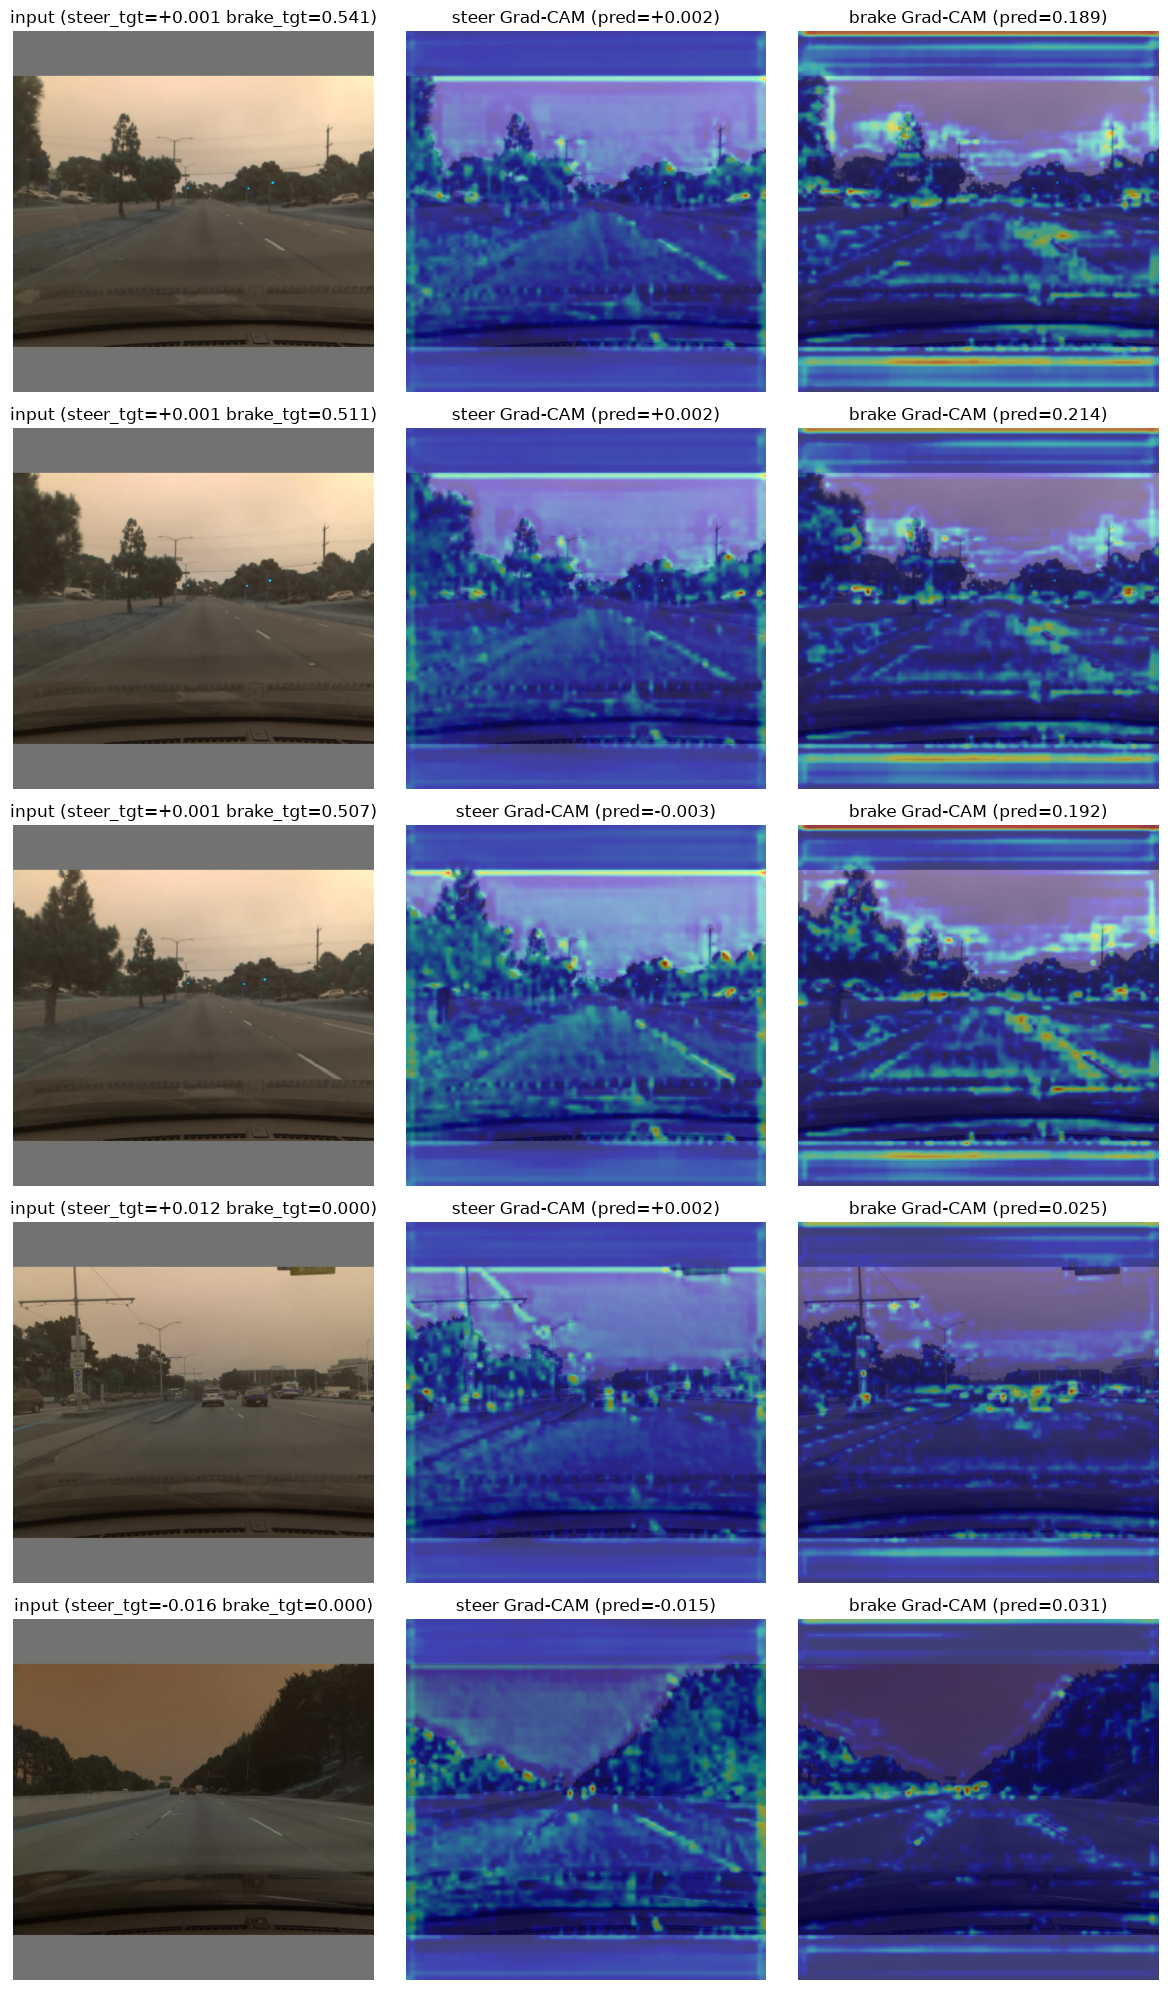

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

manifest_path = ROOT / "data" / "comma2k19" / "manifest.csv"
frames_root = ROOT / "data" / "comma2k19" / "frames"
test_df = pd.read_csv(manifest_path).pipe(lambda d: d[d["split"] == "test"]).reset_index(drop=True)

N_HARD_BRAKE = 3
N_CALM = 2
hard_brake_rows = test_df.nlargest(N_HARD_BRAKE, "brake_target")
calm_rows = test_df[test_df["brake_target"] < 0.05].sample(N_CALM, random_state=0)
sample_rows = pd.concat([hard_brake_rows, calm_rows]).reset_index(drop=True)

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(len(sample_rows), 3, figsize=(12, 4 * len(sample_rows)))
for i, row in sample_rows.iterrows():
    img_bgr = cv2.imread(str(frames_root / row["image_path"]))
    image_tensor = preprocess_image_bgr(img_bgr).unsqueeze(0).to(device)
    numeric_tensor = torch.tensor(
        [[row["throttle_t"], row["brake_t"], row["steer_t"], row["speed_t"]]],
        dtype=torch.float32, device=device,
    )
    with torch.no_grad():
        pred = control_model(image_tensor, numeric_tensor)[0].cpu().numpy()

    canvas = image_tensor[0].cpu().numpy().transpose(1, 2, 0)
    canvas = (canvas * IMAGENET_STD + IMAGENET_MEAN) * 255.0
    canvas_bgr = np.clip(canvas, 0, 255).astype(np.uint8)

    steer_cam = cam_tool(image_tensor, numeric_tensor, target="steer")
    brake_cam = cam_tool(image_tensor, numeric_tensor, target="brake")

    axes[i, 0].imshow(canvas_bgr[:, :, ::-1])
    axes[i, 0].set_title(f"input (steer_tgt={row['steer_target']:+.3f} brake_tgt={row['brake_target']:.3f})")
    axes[i, 1].imshow(overlay_heatmap(canvas_bgr, steer_cam)[:, :, ::-1])
    axes[i, 1].set_title(f"steer Grad-CAM (pred={pred[0]:+.3f})")
    axes[i, 2].imshow(overlay_heatmap(canvas_bgr, brake_cam)[:, :, ::-1])
    axes[i, 2].set_title(f"brake Grad-CAM (pred={pred[1]:.3f})")
    for ax in axes[i]:
        ax.axis("off")

plt.tight_layout()
plt.show()

## Notes / next steps

* This model was fine-tuned on real-world Comma2k19 dashcam footage, then dropped into a
  simulator it never saw during training -- expect a real sim-to-real domain gap. If the car
  drives erratically, that gap (not a bug in this loop) is the most likely cause; the per-channel
  test MAE printed in `1 Fine Tuning.ipynb` (section 7) is the baseline to compare against.
* `YOLOPControlNet` only outputs `(steer, brake)`; throttle always comes from
  `cruise_control_throttle` in this notebook. If you still see straight-line runaways under
  bridges/shadows, check that `1 Fine Tuning.ipynb` was retrained with
  `build_train_augmentations()` enabled (shadows/Cutout/brightness jitter) and
  `detach_brake_grad=True` (the default) -- both exist specifically to stop that failure mode.
* `plan.md` / `pipeline.md` / `NEXT_STEPS.md` describe the classical alternative: hand-written
  PID controllers for LKA (lane centroid error) and ACC (pinhole-distance to the lead car) built
  directly on top of `yolop_beamng.py`'s YOLOP segmentation/detection output, with no learned
  control head. That's a good sanity-check baseline to compare this learned model's behavior
  against, and the right place to start once you remove telemetry inputs to push the system
  toward vision-only estimation (the paper's sensitivity-analysis step in `plan.md`).